# TikTok Engagement Patterns

**PUBH 1142 Final Project | Jenna Escheik**

## Introduction

Social media engagement is shaped by a combination of platform features and creator characteristics. On TikTok, factors such as verification status and audience size may influence how widely content is seen and how users interact with it. Understanding these relationships is important for identifying what drives content performance on the platform.

This project investigates whether verified creators receive higher engagement than unverified creators and examines how follower count relates to engagement levels. Using a public TikTok dataset, the analysis compares engagement metrics such as likes and comments across different creator groups and explores patterns in audience interaction.

To address this research question, the dataset is first cleaned and prepared by verifying data types and handling missing values. Engagement metrics are then summarized and visualized to identify trends and differences between groups. Finally, statistical tests are used to determine whether observed differences are significant and to evaluate the relationship between follower count and engagement.

Overall, this analysis aims to provide a data-driven understanding of how verification status and audience size contribute to engagement on TikTok.


## Background

TikTok has become a major platform for information discovery and social influence, especially among Gen Z and young adults. Unlike traditional media, TikTok relies heavily on algorithmic recommendation and hashtag-based discovery, which can rapidly amplify content to large audiences. Because the platform’s visibility is driven by engagement (likes, comments, shares), it is useful to study how engagement behaves across different types of content and creator characteristics.

From a health data science perspective, engagement patterns matter because online attention is not the same as accuracy or quality. Content can spread widely because it is emotionally compelling, visually appealing, or easy to consume, even when the underlying information is weak. Studying engagement helps explain what gets amplified and what is most likely to reach large populations.

This project uses a public TikTok dataset containing video-level engagement metrics and creator metadata. The analysis focuses on whether engagement differs across creator groups using a category variable (verification status). The goal is not to judge content quality, but to quantify measurable differences in engagement patterns and demonstrate a reproducible workflow for analyzing real-world social media data.

## Methods

### Dataset
- **Source:** Kaggle dataset “TikTok Dataset” by Muhammad Anas Mahmood 
 
  https://www.kaggle.com/datasets/muhammadanasmahmood/tiktok-dataset
- **What each row represents:** One TikTok video record with associated creator metadata and engagement variables.
- **Key variables used in this analysis:**
  - `diggCount` (likes)
  - `commentCount` (comments)
  - `authorMeta/fans` (creator follower count)
  - `authorMeta/verified` (verification status; used as the category variable)

### Software
- Python (Jupyter Notebook in VS Code)
- Libraries: numpy, pandas, scipy, matplotlib, seaborn
- GitHub used for version control and assignment submission.

### Statistical Plan
1. Import and verify the dataset (shape, columns, missing values, data types).
2. Define the **category** variable as creator verification status (verified vs not verified).
3. Perform exploratory analysis:
   - frequency and percentages of the category column
   - summary statistics overall and by category
   - distribution plots (log-scaled when needed due to skew)
4. Test group differences:
   - check normality within each group (Shapiro-Wilk for smaller samples; visual checks for large samples)
   - if approximately normal and variances are similar: **Student’s t-test**
   - if approximately normal but variances differ: **Welch’s t-test**
   - if not normal: compare groups using a non-parametric alternative (Mann–Whitney U)
5. If comparing more than two groups (e.g., top hashtags): use **ANOVA** (or Kruskal–Wallis if not normal).

In [26]:
%pip install statsmodels scikit-learn
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
%config InlineBackend.figure_format = "retina"



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd

df = pd.read_csv("TiktokDataSet.csv")

df.head()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Table 1
authorMeta/avatar,authorMeta/digg,authorMeta/fans,authorMeta/following,authorMeta/heart,authorMeta/id,authorMeta/name,authorMeta/nickName,authorMeta/signature,authorMeta/verified,authorMeta/video,commentCount,createTime,createTimeISO,diggCount,downloaded,effectStickers/0/ID,effectStickers/0/name,effectStickers/0/stickerStats/useCount,effectStickers/1/ID,effectStickers/1/name,effectStickers/1/stickerStats/useCount,hashtags/0/cover,hashtags/0/id,hashtags/0/name,hashtags/0/title,hashtags/1/cover,hashtags/1/id,hashtags/1/name,hashtags/1/title,id,mediaUrls/0,mentions/0,mentions/1,mentions/2,mentions/3,mentions/4,mentions/5,musicMeta/musicAlbum,musicMeta/musicAuthor,musicMeta/musicName,musicMeta/musicOriginal,musicMeta/playUrl,playCount,searchHashtag/name,searchHashtag/views,shareCount,text,videoMeta/duration,videoMeta/height,videoMeta/width,webVideoUrl
https://p16-sign-sg.tiktokcdn.com/aweme/720x720/tos-alisg-avt-0068/3d7f8d376e2ae1e5bf2d5d34ce4227cf.jpeg?x-expires=1659128400&x-signature=fP%2BSSNIqUeMNNLO5Az7FN27SJ1k%3D,420,13200000,28,150400000,6713126981665686530,miso_ara,미소아라 Miso_Ara,soonent@soon-ent.co.kr\n.\n Miso Ara IG,true,303,66000,1582632666,2020-02-25T12:11:06.000Z,19300000,false,nan,nan,nan,nan,nan,nan,https://p16-amd-va.tiktokcdn.com/obj/musically-maliva-obj/1e6b1debcaef7ccdb2ad6107feb180b8,20408,woah,"Wait... one second... okay, WOAH!",https://p16-sg.tiktokcdn.com/obj/tiktok-obj/1641017550056449.PNG,3780738,woahchallenge,"Woah woah woah, stop right there! Have you done the latest dance challange yet! Dab, floss, or just show off your moves with the #WoahChallenge!",6797294685082619137,https://v16-webapp.tiktok.com/c5e1c65e3846e6fe306f3bee52c825e4/62e2021c/video/n/v0102/e99ec24738854b7985d2926c1410767d/?a=1988&ch=0&cr=0&dr=0&lr=tiktok&cd=0%7C0%7C1%7C0&cv=1&br=1492&bt=746&btag=80000&cs=0&ds=3&ft=gKSYZ8beo0PD1.hipsg9w.FE75LiaQ2D~j8&mime_type=video_mp4&qs=0&rc=NDplM2VlNTY4NDNoPGRkN0BpM286bGxvazZqczMzPDgzM0BgLjIxLy9iXjAxY2EzXmAvYSNvNTFkZm1rcF5fLS00LzRzcw%3D%3D&l=202207272127060102230831572562751B,nan,nan,nan,nan,nan,nan,nan,미소아라 Miso_Ara,오리지널 사운드 - Miso_Ara,true,https://sf16-ies-music-sg.tiktokcdn.com/obj/tiktok-obj/1659493776138258.mp3,200600000,meme,556B,377700,Ara Woah #woah #woahchallenge #foryou #fyp #meme #이아라 #틱톡 #tiktok,17,1280,720,https://www.tiktok.com/@miso_ara/video/6797294...
https://p16-sign-va.tiktokcdn.com/tos-maliva-avt-0068/481098764045c3ce40803bbb7a4ce8f5~c5_720x720.jpeg?x-expires=1659128400&x-signature=SgmuV2iwipES%2BPUxZ0e%2Bl8xaCRA%3D,10800,1300000,182,35100000,6929583089811522566,crinka11,Chris Rinker,insta: chrisrinker73,false,518,154100,1620176163,2021-05-05T00:56:03.000Z,15400000,false,nan,nan,nan,nan,nan,nan,nan,229207,fyp,nan,https://p16-amd-va.tiktokcdn.com/obj/musically-maliva-obj/c9361f827e1dcb19d2e54e58654c9f55.jpeg,23864,meme,nan,6958603581675031814,https://v16-webapp.tiktok.com/fcc73bd189606c1de0970ba0a9307e3d/62e20215/video/tos/useast2a/tos-useast2a-ve-0068c002/3e9a31d1340143e1ad520396bf4f585a/?a=1988&ch=0&cr=0&dr=0&lr=tiktok_m&cd=0%7C0%7C1%7C0&cv=1&br=1380&bt=690&btag=80000&cs=0&ds=3&ft=gKSYZ8beo0PD1khipsg9w.FE75LiaQ2D~j8&mime_type=video_mp4&qs=0&rc=OTM0PDxmNDw0OGc7ZDU5M0BpanVpc3U7dTh4NTMzNzczM0A2MGMtMTQtXzIxXi0tMC4zYSNmYzJsM2xebjVgLS1kMTZzcw%3D%3D&l=202207272127060102230831572562751B,nan,nan,nan,nan,nan,nan,nan,Chris Rinker,original sound,true,https://sf16-ies-music-va.tiktokcdn.com/obj/musically-maliva-obj/6958603596321655557.mp3,79600000,meme,556B,205400,#fyp #meme #funny #meme #vine,11,1024,576,https://www.tiktok.com/@crinka11/video/6958603...
https://p16-sign-va.tiktokcdn.com/tos-maliva-avt-0068/25e7644ef6de2fda3ceb6b3ded7ec1e6~c5_720x720.jpeg?x-expires=1659128400&x-signature=e%2BwijcH%2B%2BQDtDjI%2B1Xi98ORpxkc%3D,251,696800,42,15900000,7083448802635596842,iampets_com,IamPéts,"Pet supplies, toys online store. All products in our video can buy in below link",false,90,55300,1649340306,2022-04-07T14:05:06.000Z,13900000,false,n

In [28]:
df = pd.read_csv("TiktokDataSet.csv", header=1)
df.shape, df.columns


((1200, 52),
 Index(['authorMeta/avatar', 'authorMeta/digg', 'authorMeta/fans',
        'authorMeta/following', 'authorMeta/heart', 'authorMeta/id',
        'authorMeta/name', 'authorMeta/nickName', 'authorMeta/signature',
        'authorMeta/verified', 'authorMeta/video', 'commentCount', 'createTime',
        'createTimeISO', 'diggCount', 'downloaded', 'effectStickers/0/ID',
        'effectStickers/0/name', 'effectStickers/0/stickerStats/useCount',
        'effectStickers/1/ID', 'effectStickers/1/name',
        'effectStickers/1/stickerStats/useCount', 'hashtags/0/cover',
        'hashtags/0/id', 'hashtags/0/name', 'hashtags/0/title',
        'hashtags/1/cover', 'hashtags/1/id', 'hashtags/1/name',
        'hashtags/1/title', 'id', 'mediaUrls/0', 'mentions/0', 'mentions/1',
        'mentions/2', 'mentions/3', 'mentions/4', 'mentions/5',
        'musicMeta/musicAlbum', 'musicMeta/musicAuthor', 'musicMeta/musicName',
        'musicMeta/musicOriginal', 'musicMeta/playUrl', 'playCount',
  

## Data Cleaning

In [29]:
df = pd.read_csv("TiktokDataSet.csv")
df.head(10)

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Table 1
authorMeta/avatar,authorMeta/digg,authorMeta/fans,authorMeta/following,authorMeta/heart,authorMeta/id,authorMeta/name,authorMeta/nickName,authorMeta/signature,authorMeta/verified,authorMeta/video,commentCount,createTime,createTimeISO,diggCount,downloaded,effectStickers/0/ID,effectStickers/0/name,effectStickers/0/stickerStats/useCount,effectStickers/1/ID,effectStickers/1/name,effectStickers/1/stickerStats/useCount,hashtags/0/cover,hashtags/0/id,hashtags/0/name,hashtags/0/title,hashtags/1/cover,hashtags/1/id,hashtags/1/name,hashtags/1/title,id,mediaUrls/0,mentions/0,mentions/1,mentions/2,mentions/3,mentions/4,mentions/5,musicMeta/musicAlbum,musicMeta/musicAuthor,musicMeta/musicName,musicMeta/musicOriginal,musicMeta/playUrl,playCount,searchHashtag/name,searchHashtag/views,shareCount,text,videoMeta/duration,videoMeta/height,videoMeta/width,webVideoUrl
https://p16-sign-sg.tiktokcdn.com/aweme/720x720/tos-alisg-avt-0068/3d7f8d376e2ae1e5bf2d5d34ce4227cf.jpeg?x-expires=1659128400&x-signature=fP%2BSSNIqUeMNNLO5Az7FN27SJ1k%3D,420,13200000,28,150400000,6713126981665686530,miso_ara,미소아라 Miso_Ara,soonent@soon-ent.co.kr\n.\n Miso Ara IG,true,303,66000,1582632666,2020-02-25T12:11:06.000Z,19300000,false,nan,nan,nan,nan,nan,nan,https://p16-amd-va.tiktokcdn.com/obj/musically-maliva-obj/1e6b1debcaef7ccdb2ad6107feb180b8,20408,woah,"Wait... one second... okay, WOAH!",https://p16-sg.tiktokcdn.com/obj/tiktok-obj/1641017550056449.PNG,3780738,woahchallenge,"Woah woah woah, stop right there! Have you done the latest dance challange yet! Dab, floss, or just show off your moves with the #WoahChallenge!",6797294685082619137,https://v16-webapp.tiktok.com/c5e1c65e3846e6fe306f3bee52c825e4/62e2021c/video/n/v0102/e99ec24738854b7985d2926c1410767d/?a=1988&ch=0&cr=0&dr=0&lr=tiktok&cd=0%7C0%7C1%7C0&cv=1&br=1492&bt=746&btag=80000&cs=0&ds=3&ft=gKSYZ8beo0PD1.hipsg9w.FE75LiaQ2D~j8&mime_type=video_mp4&qs=0&rc=NDplM2VlNTY4NDNoPGRkN0BpM286bGxvazZqczMzPDgzM0BgLjIxLy9iXjAxY2EzXmAvYSNvNTFkZm1rcF5fLS00LzRzcw%3D%3D&l=202207272127060102230831572562751B,nan,nan,nan,nan,nan,nan,nan,미소아라 Miso_Ara,오리지널 사운드 - Miso_Ara,true,https://sf16-ies-music-sg.tiktokcdn.com/obj/tiktok-obj/1659493776138258.mp3,200600000,meme,556B,377700,Ara Woah #woah #woahchallenge #foryou #fyp #meme #이아라 #틱톡 #tiktok,17,1280,720,https://www.tiktok.com/@miso_ara/video/6797294...
https://p16-sign-va.tiktokcdn.com/tos-maliva-avt-0068/481098764045c3ce40803bbb7a4ce8f5~c5_720x720.jpeg?x-expires=1659128400&x-signature=SgmuV2iwipES%2BPUxZ0e%2Bl8xaCRA%3D,10800,1300000,182,35100000,6929583089811522566,crinka11,Chris Rinker,insta: chrisrinker73,false,518,154100,1620176163,2021-05-05T00:56:03.000Z,15400000,false,nan,nan,nan,nan,nan,nan,nan,229207,fyp,nan,https://p16-amd-va.tiktokcdn.com/obj/musically-maliva-obj/c9361f827e1dcb19d2e54e58654c9f55.jpeg,23864,meme,nan,6958603581675031814,https://v16-webapp.tiktok.com/fcc73bd189606c1de0970ba0a9307e3d/62e20215/video/tos/useast2a/tos-useast2a-ve-0068c002/3e9a31d1340143e1ad520396bf4f585a/?a=1988&ch=0&cr=0&dr=0&lr=tiktok_m&cd=0%7C0%7C1%7C0&cv=1&br=1380&bt=690&btag=80000&cs=0&ds=3&ft=gKSYZ8beo0PD1khipsg9w.FE75LiaQ2D~j8&mime_type=video_mp4&qs=0&rc=OTM0PDxmNDw0OGc7ZDU5M0BpanVpc3U7dTh4NTMzNzczM0A2MGMtMTQtXzIxXi0tMC4zYSNmYzJsM2xebjVgLS1kMTZzcw%3D%3D&l=202207272127060102230831572562751B,nan,nan,nan,nan,nan,nan,nan,Chris Rinker,original sound,true,https://sf16-ies-music-va.tiktokcdn.com/obj/musically-maliva-obj/6958603596321655557.mp3,79600000,meme,556B,205400,#fyp #meme #funny #meme #vine,11,1024,576,https://www.tiktok.com/@crinka11/video/6958603...
https://p16-sign-va.tiktokcdn.com/tos-maliva-avt-0068/25e7644ef6de2fda3ceb6b3ded7ec1e6~c5_720x720.jpeg?x-expires=1659128400&x-signature=e%2BwijcH%2B%2BQDtDjI%2B1Xi98ORpxkc%3D,251,696800,42,15900000,7083448802635596842,iampets_com,IamPéts,"Pet supplies, toys online store. All products in our video can buy in below link",false,90,55300,1649340306,2022-04-07T14:05:06.000Z,13900000,false,n

In [30]:
df = pd.read_csv("TiktokDataSet.csv", header=1)
df.columns

Index(['authorMeta/avatar', 'authorMeta/digg', 'authorMeta/fans',
       'authorMeta/following', 'authorMeta/heart', 'authorMeta/id',
       'authorMeta/name', 'authorMeta/nickName', 'authorMeta/signature',
       'authorMeta/verified', 'authorMeta/video', 'commentCount', 'createTime',
       'createTimeISO', 'diggCount', 'downloaded', 'effectStickers/0/ID',
       'effectStickers/0/name', 'effectStickers/0/stickerStats/useCount',
       'effectStickers/1/ID', 'effectStickers/1/name',
       'effectStickers/1/stickerStats/useCount', 'hashtags/0/cover',
       'hashtags/0/id', 'hashtags/0/name', 'hashtags/0/title',
       'hashtags/1/cover', 'hashtags/1/id', 'hashtags/1/name',
       'hashtags/1/title', 'id', 'mediaUrls/0', 'mentions/0', 'mentions/1',
       'mentions/2', 'mentions/3', 'mentions/4', 'mentions/5',
       'musicMeta/musicAlbum', 'musicMeta/musicAuthor', 'musicMeta/musicName',
       'musicMeta/musicOriginal', 'musicMeta/playUrl', 'playCount',
       'searchHashtag/name', 

In [31]:
# Convert to numeric
df["diggCount"] = pd.to_numeric(df["diggCount"], errors="coerce")
df["commentCount"] = pd.to_numeric(df["commentCount"], errors="coerce")
df["authorMeta/fans"] = pd.to_numeric(df["authorMeta/fans"], errors="coerce")

In [32]:
# Drop missing values
df = df.dropna(subset=["diggCount", "commentCount", "authorMeta/fans"])

In [33]:
# Convert verified to boolean
df["authorMeta/verified"] = df["authorMeta/verified"].astype(bool)

In [34]:
df[["diggCount", "commentCount", "authorMeta/fans"]].describe()

,diggCount,commentCount,authorMeta/fans
count,1.200000e+03,1200.000000,1.200000e+03
mean,6.577728e+06,53554.415000,7.124049e+06
std,5.867806e+06,74139.653978,2.096570e+07
min,9.670000e+02,0.000000,4.180000e+02
25%,1.900000e+06,8459.000000,2.792000e+05
50%,5.700000e+06,29500.000000,1.300000e+06
75%,9.025000e+06,70500.000000,4.525000e+06
max,3.720000e+07,715500.000000,1.475000e+08


In [35]:
df.groupby("authorMeta/verified")[["diggCount", "commentCount"]].agg(["mean","median","std"])

diggCount                           commentCount  \
                             mean     median           std          mean   
authorMeta/verified                                                        
False                5.619418e+06  4800000.0  5.197944e+06  50282.759450   
True                 9.136154e+06  7800000.0  6.733439e+06  62288.834862   

                                            
                      median           std  
authorMeta/verified                         
False                23000.0  74618.058447  
True                 40300.0  72235.742102

In [36]:
import numpy as np

df["log_diggs"] = np.log1p(df["diggCount"])
df["log_fans"] = np.log1p(df["authorMeta/fans"])

In [37]:
from scipy import stats

verified = df[df["authorMeta/verified"] == True]["diggCount"]
unverified = df[df["authorMeta/verified"] == False]["diggCount"]

stats.mannwhitneyu(verified, unverified)

MannwhitneyuResult(statistic=np.float64(190301.0), pvalue=np.float64(5.640586275037764e-19))

# Results

## Descriptive Statistics

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["axes.titlepad"] = 12
plt.rcParams["figure.facecolor"] = "#FCE7F3"
plt.rcParams["axes.facecolor"] = "#FCE7F3"

In [40]:
cat_col = "category"

In [41]:
# Summary statistics
df[["diggCount", "commentCount", "authorMeta/fans"]].describe()

# Median
df[["diggCount", "commentCount", "authorMeta/fans"]].median()

# Range
(df[["diggCount", "commentCount", "authorMeta/fans"]].max() -
 df[["diggCount", "commentCount", "authorMeta/fans"]].min())

# Mode
df[["diggCount", "commentCount", "authorMeta/fans"]].mode()

,diggCount,commentCount,authorMeta/fans
0,1200000.0,20500.0,1300000
1,NaN,NaN,147500000


In [42]:
df["authorMeta/verified"].value_counts()
df["authorMeta/verified"].value_counts(normalize=True)

authorMeta/verified
False    0.7275
True     0.2725
Name: proportion, dtype: float64

### Interpretation

The dataset contains 1,200 observations. Engagement metrics such as likes and comments show high variability, with large differences between mean and median values, indicating a right-skewed distribution.

Follower counts are also highly skewed, with a small number of creators having extremely large audiences.

The distribution of verified versus unverified creators provides a basis for comparing engagement between these groups in later analysis.


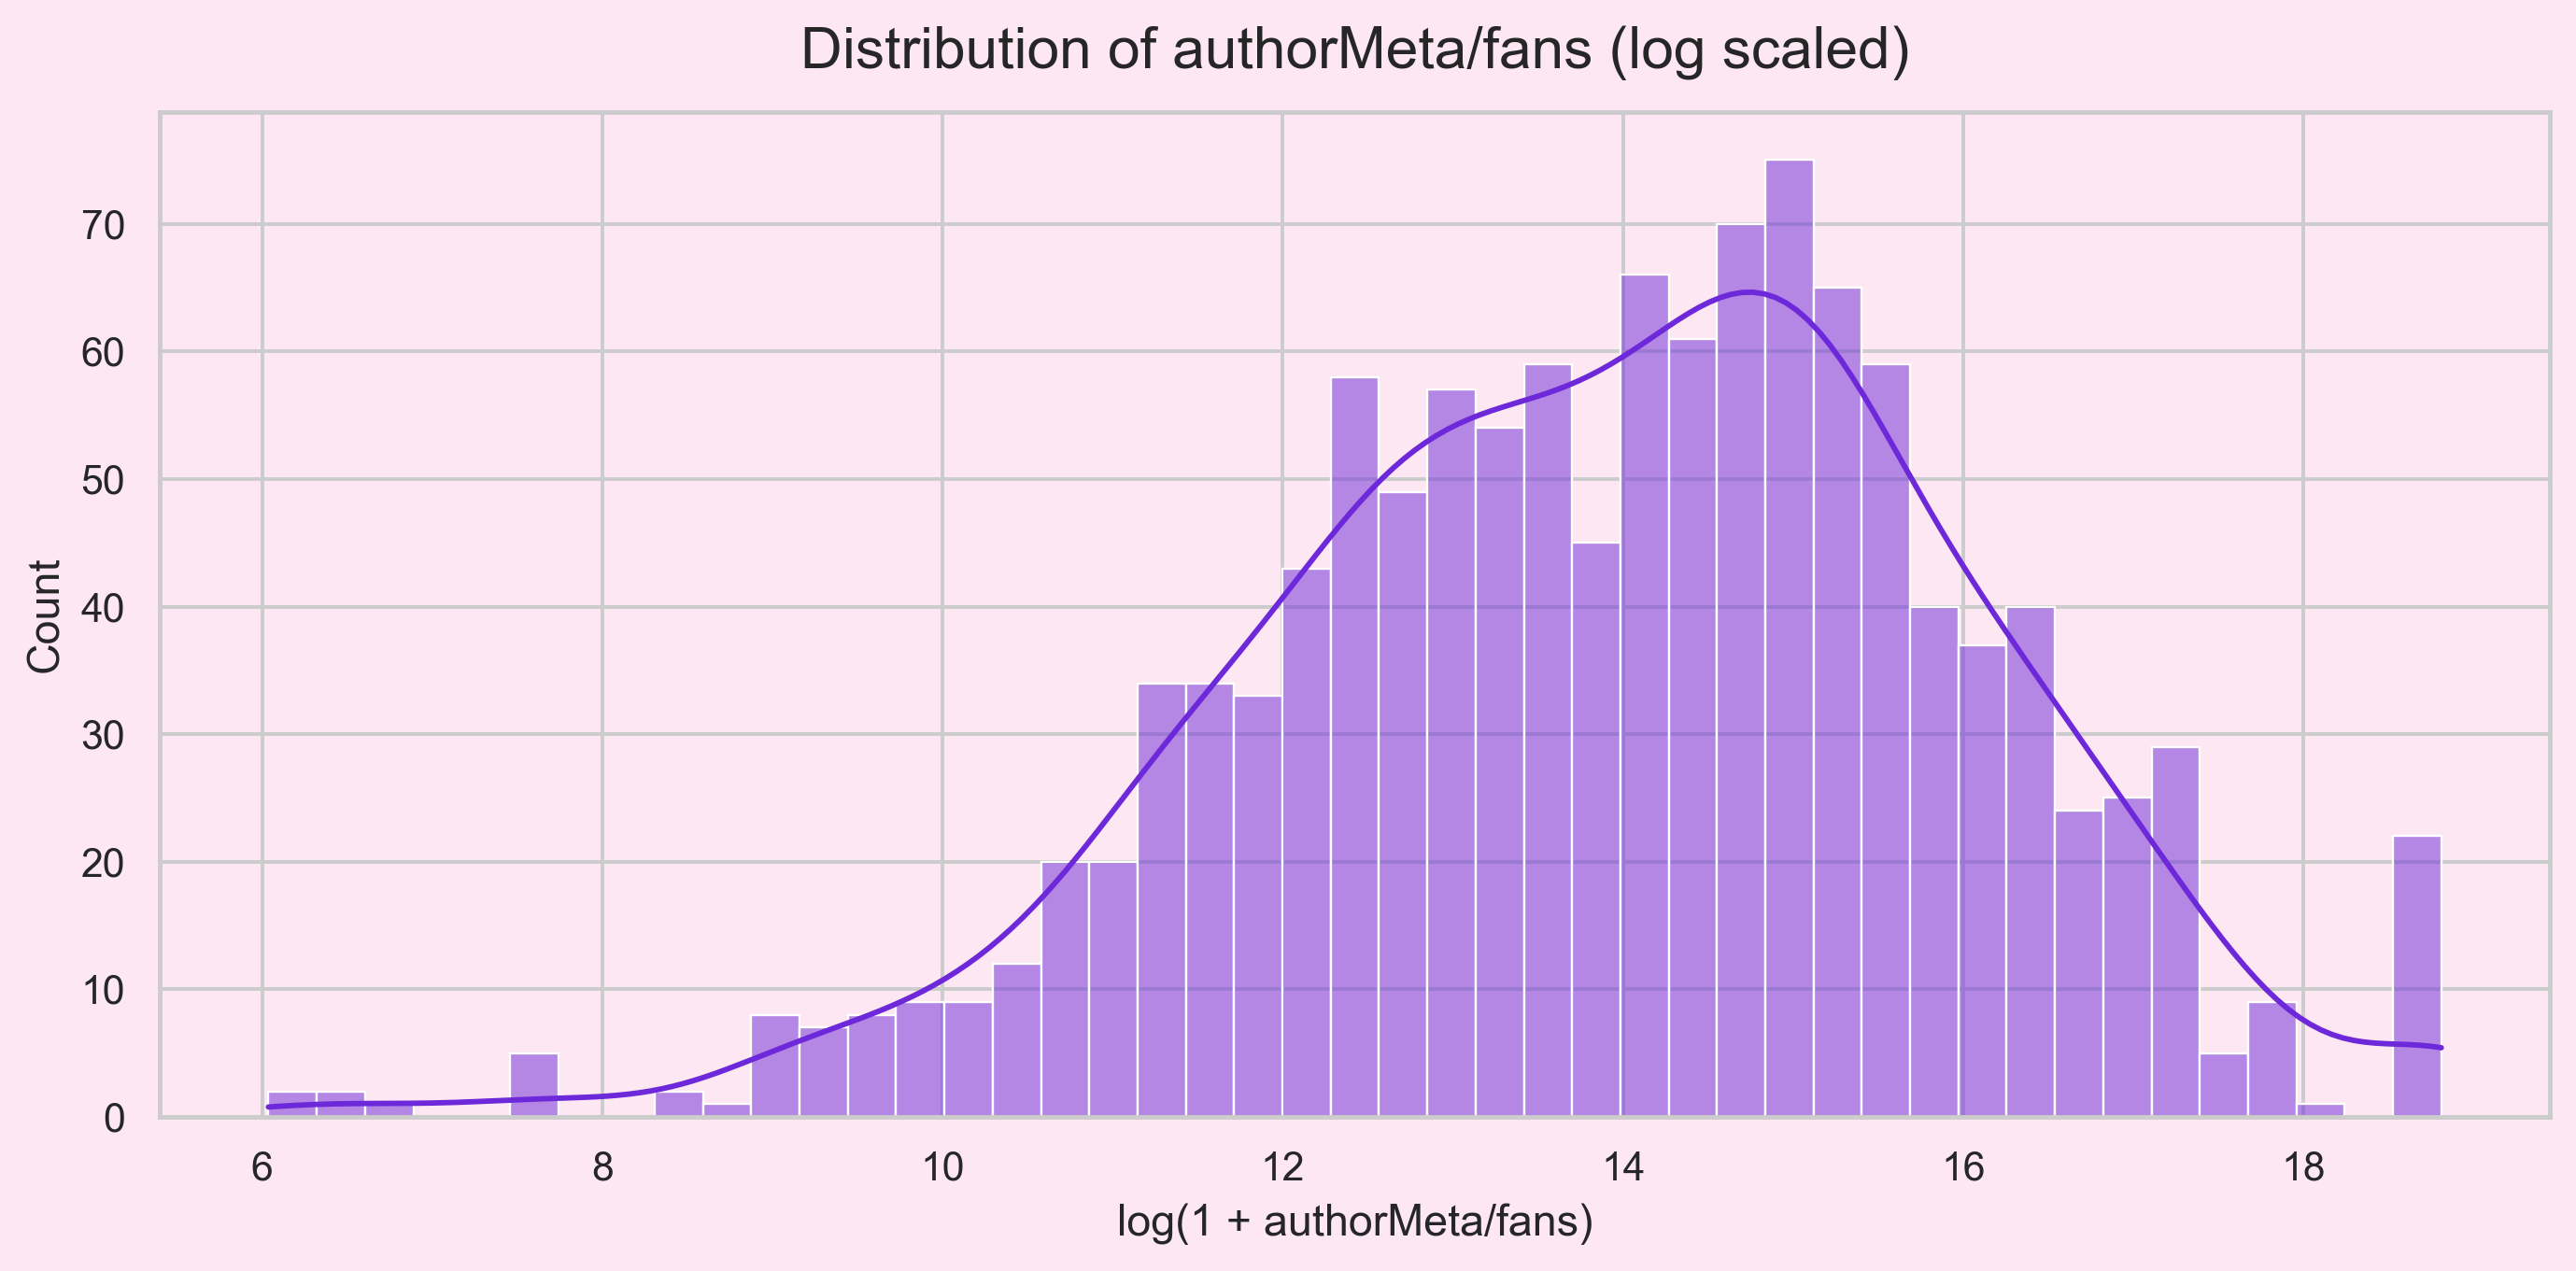

In [43]:
col = "authorMeta/fans"  # change if needed
x = pd.to_numeric(df[col], errors="coerce").dropna()
x_log = np.log1p(x)

plt.figure(figsize=(10, 5))
sns.histplot(x_log, bins=45, kde=True, color="#6D28D9", edgecolor="white", linewidth=0.6)
plt.title(f"Distribution of {col} (log scaled)")
plt.xlabel(f"log(1 + {col})")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/var/folders/d6/6lrystcn6v14_yr55ybj2_640000gn/T/ipykernel_1419/2470445779.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


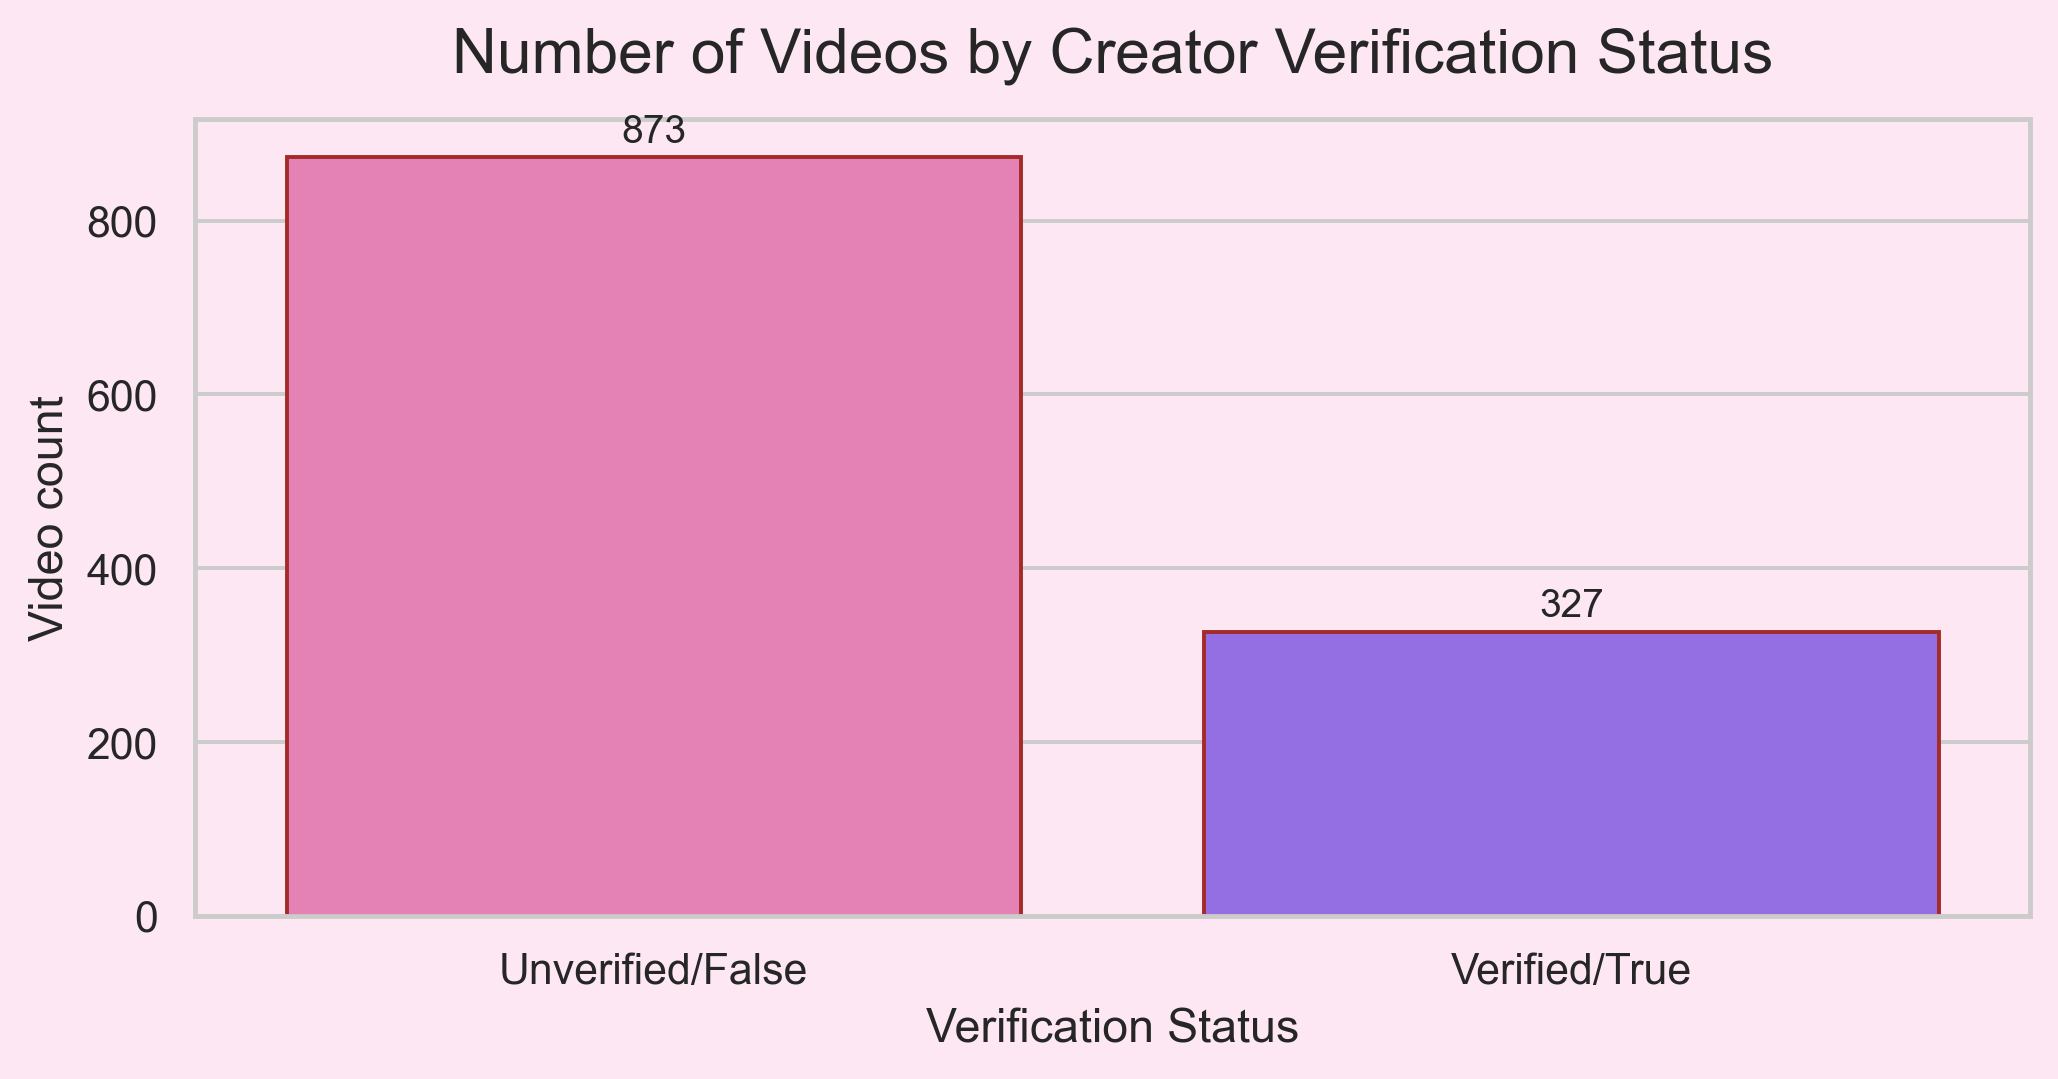

In [44]:
cat_col = "authorMeta/verified"

# Clean + force booleans
counts = (
    df[cat_col]
    .fillna(False)
    .astype(bool)
    .value_counts()
    .reindex([False, True])   # order: False then True
)

plt.figure(figsize=(7.5, 4))
ax = sns.barplot(
    x=["Unverified/False", "Verified/True"],
    y=counts.values,
    palette=["#F472B6", "#8B5CF6"]
)

# Add 1pt black border to bars
for patch in ax.patches:
    patch.set_edgecolor('brown')
    patch.set_linewidth(1)

plt.title("Number of Videos by Creator Verification Status")
plt.xlabel("Verification Status")
plt.ylabel("Video count")

for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max()*0.02, f"{int(v)}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


/var/folders/d6/6lrystcn6v14_yr55ybj2_640000gn/T/ipykernel_1419/2203826072.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=cat_col, y="log_fans", palette=["#F472B6", "#8B5CF6"])


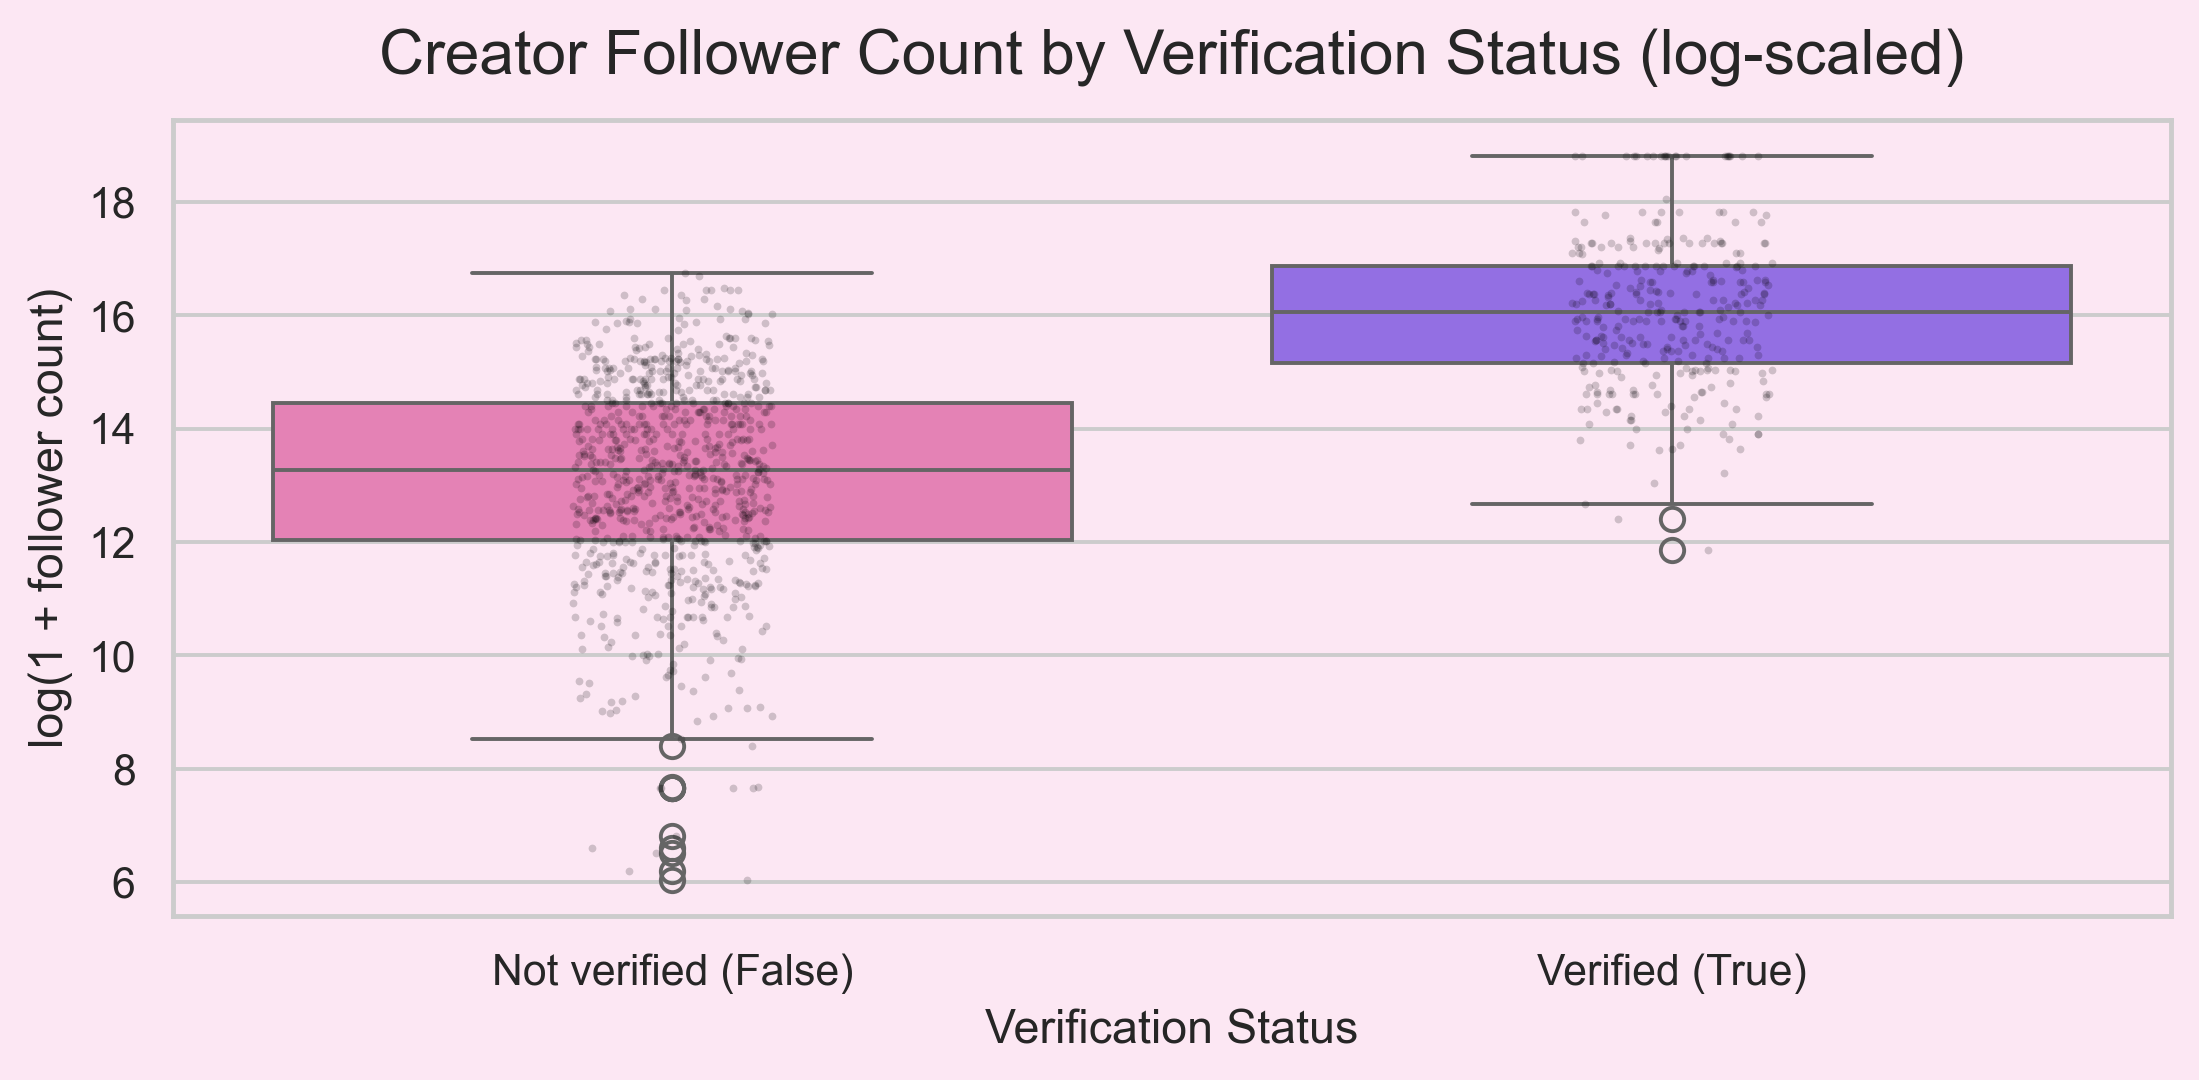

In [45]:
cat_col = "authorMeta/verified"
num_col = "authorMeta/fans"


plot_df = df[[cat_col, num_col]].copy()
plot_df[cat_col] = plot_df[cat_col].fillna(False).astype(bool)   # real booleans
plot_df[num_col] = pd.to_numeric(plot_df[num_col], errors="coerce")
plot_df = plot_df.dropna()

# Force order: False then True
plot_df[cat_col] = pd.Categorical(plot_df[cat_col], categories=[False, True], ordered=True)

# Log scale for nicer spread (fans are usually very skewed)
plot_df["log_fans"] = np.log1p(plot_df[num_col])

plt.figure(figsize=(8, 4))
sns.boxplot(data=plot_df, x=cat_col, y="log_fans", palette=["#F472B6", "#8B5CF6"])
sns.stripplot(data=plot_df, x=cat_col, y="log_fans", color="black", alpha=0.18, size=2)

plt.title("Creator Follower Count by Verification Status (log-scaled)")
plt.xlabel("Verification Status")
plt.ylabel("log(1 + follower count)")

# Make x labels look clean
plt.xticks([0, 1], ["Not verified (False)", "Verified (True)"])

plt.tight_layout()
plt.show()


In [46]:
num_cols = ["diggCount", "commentCount", "authorMeta/fans", "authorMeta/heart", "authorMeta/video"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

In [47]:
import numpy as np

df["log_diggs"] = np.log1p(df["diggCount"])
df["log_fans"] = np.log1p(df["authorMeta/fans"])

## Infernetial Statistics

In [48]:
from scipy import stats

verified = df[df["authorMeta/verified"] == True]["diggCount"]
unverified = df[df["authorMeta/verified"] == False]["diggCount"]

stat, p_value = stats.mannwhitneyu(verified, unverified)

print("Mann-Whitney U:", stat)
print("P-value:", p_value)

Mann-Whitney U: 190301.0
P-value: 5.640586275037764e-19


### Interpretation of Group Difference

A Mann–Whitney U test was conducted to compare engagement between verified and unverified creators.

If the p-value is less than 0.05, the difference in engagement is statistically significant, meaning verification status likely impacts engagement.

If the p-value is greater than 0.05, there is no strong statistical evidence of a difference.


In [49]:
corr, p = stats.pearsonr(df["log_fans"], df["log_diggs"])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.5255506273532571
P-value: 3.559160794130115e-86


### Interpretation of Correlation

A Pearson correlation test was conducted to examine the relationship between follower count and engagement.

The correlation coefficient indicates the strength and direction of the relationship between these variables.

A positive correlation suggests that creators with more followers tend to receive higher engagement.


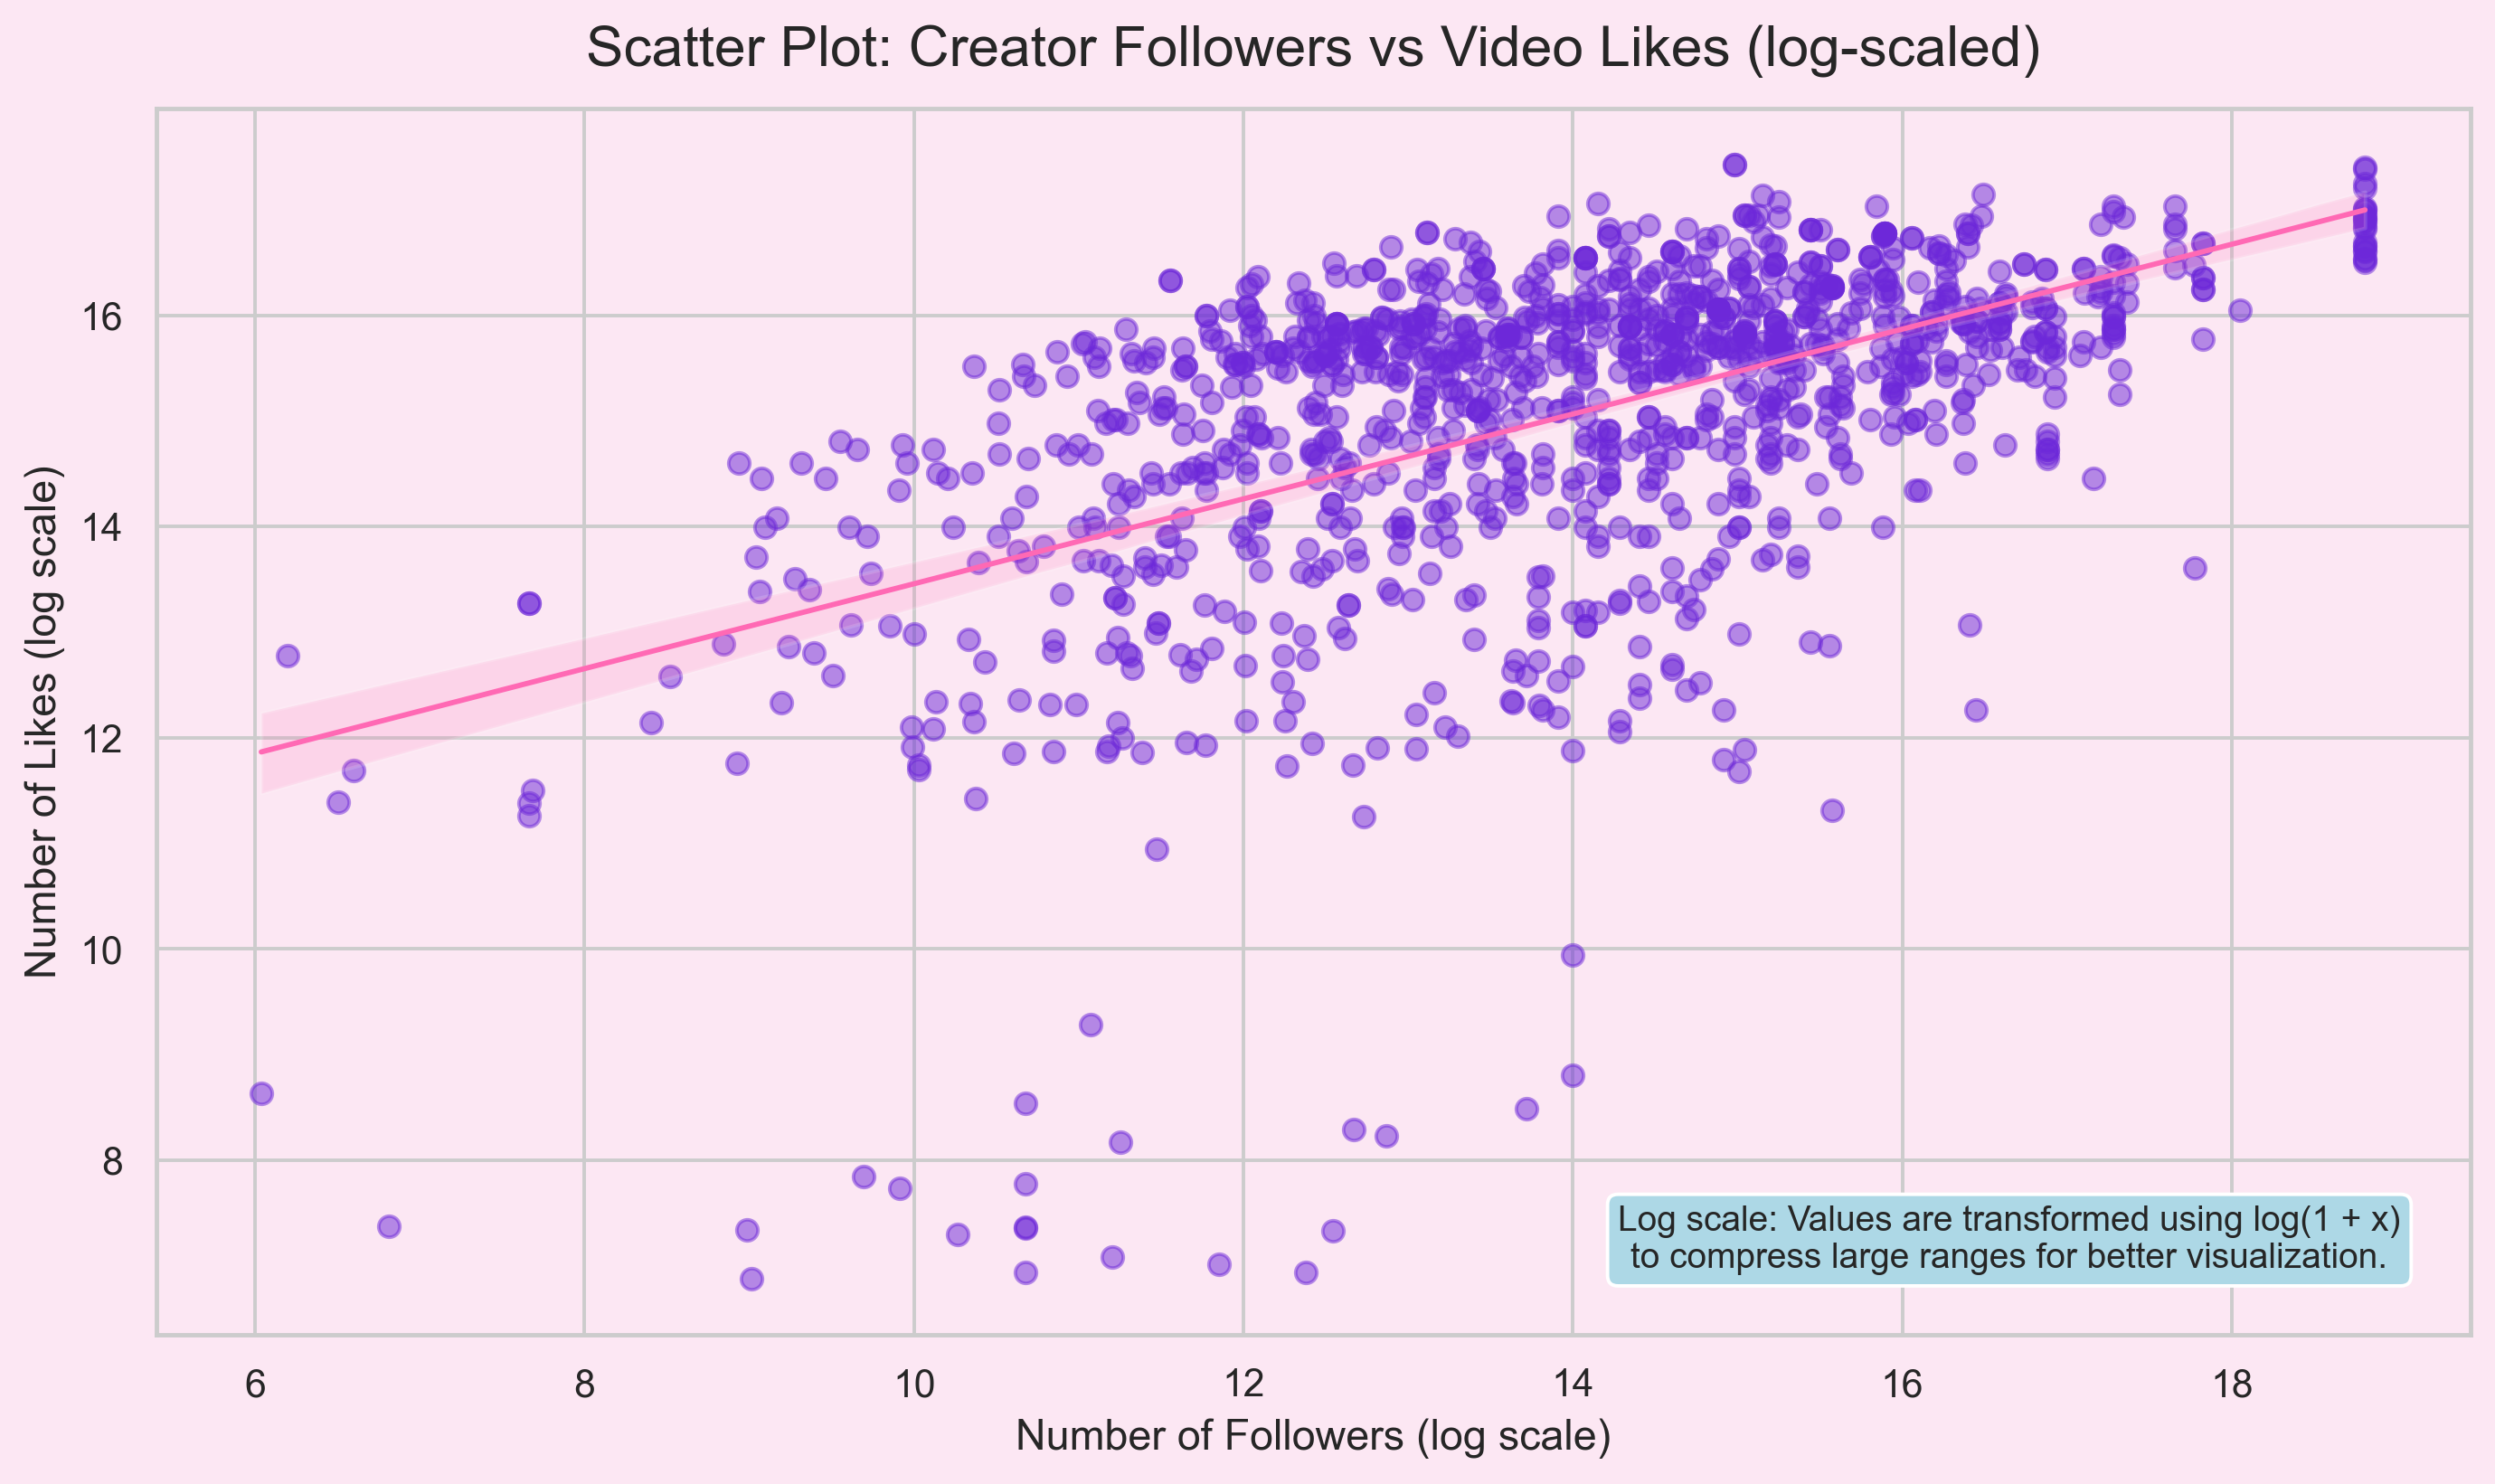

In [50]:
# Scatter plot with regression line: log-scaled fans vs log-scaled diggCount
x_col = "authorMeta/fans"
y_col = "diggCount"

# Prepare data
scatter_df = df[[x_col, y_col]].copy()
scatter_df[x_col] = pd.to_numeric(scatter_df[x_col], errors="coerce")
scatter_df[y_col] = pd.to_numeric(scatter_df[y_col], errors="coerce")
scatter_df = scatter_df.dropna()

# Log transform for better visualization
scatter_df["log_fans"] = np.log1p(scatter_df[x_col])
scatter_df["log_diggs"] = np.log1p(scatter_df[y_col])

plt.figure(figsize=(10, 6))
sns.regplot(
    data=scatter_df,
    x="log_fans",
    y="log_diggs",
    scatter_kws={"alpha": 0.5, "color": "#6D28D9"},
    line_kws={"color": "hotpink", "linewidth": 1.5}
)
plt.title("Scatter Plot: Creator Followers vs Video Likes (log-scaled)")
plt.xlabel("Number of Followers (log scale)")
plt.ylabel("Number of Likes (log scale)")
plt.figtext(0.80, 0.17, "Log scale: Values are transformed using log(1 + x)\nto compress large ranges for better visualization.",
            ha="center", va="center", fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
plt.tight_layout()
plt.show()


## Discussion

The results of this analysis provide clear evidence that both verification status and follower count influence engagement on TikTok. The statistically significant difference in engagement between verified and unverified creators suggests that verification may enhance visibility or perceived credibility, leading to higher interaction levels. Verified accounts are often prioritized by the platform’s algorithm or trusted more by users, which could explain this difference.

In addition, the moderate positive correlation between follower count and engagement indicates that audience size plays a substantial role in content performance. Creators with larger followings are more likely to reach wider audiences, increasing the likelihood of likes and comments.

However, the data also reveals a highly skewed distribution, where a small number of creators have extremely large follower counts and engagement levels. This suggests that viral content or influencer-level accounts may disproportionately affect overall trends. As a result, while follower count is an important factor, it may not fully explain engagement outcomes on its own.

There are also limitations to this analysis. The dataset does not account for other variables that may influence engagement, such as content type, posting time, or algorithmic promotion. Additionally, correlation does not imply causation, meaning that while follower count and engagement are related, one does not necessarily cause the other.

Overall, the findings highlight that both platform-related factors (such as verification) and creator-related factors (such as audience size) contribute to engagement, but further analysis would be needed to fully understand the complexity of these relationships.


## Conclusion

This analysis examined whether verification status and follower count influence engagement on TikTok.

The results of the Mann–Whitney U test showed that engagement between verified and unverified creators was statistically significant (p < 0.05), indicating that verification status is associated with differences in engagement levels.

Additionally, the correlation analysis revealed a moderate positive relationship (r = 0.53) between follower count and engagement, suggesting that creators with more followers tend to receive higher engagement.

Overall, these findings suggest that both verification status and follower count play important roles in influencing engagement on TikTok, with follower count being a particularly strong contributing factor.
